1. What do I actually have?
   → Shape, data types, missing values, duplicates

2. What am I trying to predict?
   → Understand the target variable deeply

3. What patterns exist in the data?
   → Distributions, relationships, trends

4. What's suspicious or broken?
   → Outliers, data leakage, collinear features

5. What should I engineer next?
   → EDA tells you what new features would be useful

## Notebook Structure
```
Section 1  — Setup & Configuration
Section 2  — Data Overview        (what do we have?)
Section 3  — Data Cleaning        (fix before analysing)
Section 4  — Missing Value Analysis
Section 5  — Target Variable      (what are we predicting?)
Section 6  — Feature Distributions (what does each column look like?)
Section 7  — Grid vs Finish       (the most important relationship in F1)
Section 8  — Pace Analysis        (do fast cars win?)
Section 9  — Constructor Effects  (how much does the car matter?)
Section 10 — Weather & Strategy   (does rain change everything?)
Section 11 — Correlation Analysis (what actually predicts outcomes?)
Section 12 — Summary & Decisions  (what did we learn?)
```

**Input:**  `../data/processed/master_dataset.csv`  
**Output:** `../data/processed/master_clean.csv` — cleaned, ready for feature engineering

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

print('Libraries loaded ✅')

Libraries loaded ✅


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# PROJECT CONFIGURATION
# Everything is defined once here. No column names hardcoded anywhere
# else in the notebook — always reference these dicts/lists instead.
# ══════════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────────
PATHS = {
    'input':  '../data/processed/master_dataset.csv',
    'output': '../data/processed/master_clean.csv',
    'plots':  '../data/figures/',
}

# ── Column catalogue ──────────────────────────────────────────────────
# Documents every column: source, type, and role.
# This is called a 'data dictionary' — standard in professional projects.
COLUMN_CATALOGUE = {
    # --- Identifiers (not used for modelling)
    'year':             {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'round':            {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'race_name':        {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'circuit_id':       {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'circuit_name':     {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'country':          {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'date':             {'source': 'Jolpica', 'type': 'datetime',  'role': 'identifier'},
    'driver_id':        {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'driver_code':      {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'driver_name':      {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'constructor_id':   {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    'constructor_name': {'source': 'Jolpica', 'type': 'id',        'role': 'identifier'},
    # --- Pre-race features (known BEFORE the race — safe to use)
    'grid_position':    {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'qual_position':    {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'q1_time_s':        {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'q2_time_s':        {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'q3_time_s':        {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'best_qual_time_s': {'source': 'Jolpica', 'type': 'numeric',   'role': 'pre_race_feature'},
    'air_temp_mean':    {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'air_temp_min':     {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'air_temp_max':     {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'track_temp_mean':  {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'track_temp_min':   {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'track_temp_max':   {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'wind_speed_mean':  {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'wind_speed_max':   {'source': 'FastF1',  'type': 'numeric',   'role': 'pre_race_feature'},
    'winddirection_mean':{'source': 'FastF1', 'type': 'numeric',   'role': 'pre_race_feature'},
    'country_code':     {'source': 'OpenF1',  'type': 'categorical','role': 'pre_race_feature'},
   
    # --- Post-race features (known ONLY AFTER the race — data leakage risk)
    'laps_completed':   {'source': 'Jolpica', 'type': 'numeric',   'role': 'post_race_leakage'},
    'status':           {'source': 'Jolpica', 'type': 'categorical','role': 'post_race_leakage'},
    'avg_lap_time':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'best_lap_time':    {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'std_lap_time':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'total_valid_laps': {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'laps_on_soft':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'laps_on_medium':   {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'laps_on_hard':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'avg_tyre_life':    {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'total_stints':     {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'total_pit_stops':  {'source': 'Jolpica', 'type': 'numeric',   'role': 'post_race_leakage'},
    'avg_pit_duration': {'source': 'Jolpica', 'type': 'numeric',   'role': 'post_race_leakage'},
    'first_stop_lap':   {'source': 'Jolpica', 'type': 'numeric',   'role': 'post_race_leakage'},
    'had_rain':         {'source': 'FastF1',  'type': 'boolean',   'role': 'post_race_leakage'},
    'rain_laps':        {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    'rain_fraction':    {'source': 'FastF1',  'type': 'numeric',   'role': 'post_race_leakage'},
    # --- Target variables (what we predict)
    'finish_position':  {'source': 'Jolpica', 'type': 'numeric',   'role': 'target'},
    'points':           {'source': 'Jolpica', 'type': 'numeric',   'role': 'target'},
    'on_podium':        {'source': 'Jolpica', 'type': 'boolean',   'role': 'target'},
    'points_finish':    {'source': 'Jolpica', 'type': 'boolean',   'role': 'target'},
    'finished':         {'source': 'Jolpica', 'type': 'boolean',   'role': 'target'},
        
    # --- Derived columns (created during cleaning)
    'q1_time_s':           {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'q2_time_s':           {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'q3_time_s':           {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'best_qual_time_s':    {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'track_temp_range':    {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'positions_gained':    {'source': 'derived', 'type': 'numeric',  'role': 'post_race_leakage'},
    'race_completion_pct': {'source': 'derived', 'type': 'numeric',  'role': 'post_race_leakage'},
    'season_progress':     {'source': 'derived', 'type': 'numeric',  'role': 'pre_race_feature'},
    'top_10':              {'source': 'derived', 'type': 'boolean',  'role': 'target'},
}

# Derived lists from catalogue — so code never has hardcoded column names
TARGETS           = [c for c, m in COLUMN_CATALOGUE.items() if m['role'] == 'target']
PRE_RACE_FEATURES = [c for c, m in COLUMN_CATALOGUE.items() if m['role'] == 'pre_race_feature']
LEAKAGE_COLS      = [c for c, m in COLUMN_CATALOGUE.items() if m['role'] == 'post_race_leakage']
IDENTIFIERS       = [c for c, m in COLUMN_CATALOGUE.items() if m['role'] == 'identifier']

# ── Visual style ──────────────────────────────────────────────────────
# Defined once — all plots use these automatically
STYLE = {
    'bg_dark':   '#0f0f0f',
    'bg_panel':  '#1a1a1a',
    'red':       '#e8002d',   # F1 red
    'white':     '#ffffff',
    'silver':    '#c0c0c0',
    'gold':      '#ffd700',
    'blue':      '#0093cc',
    'orange':    '#ff8000',
    'grid':      '#2a2a2a',
}

plt.rcParams.update({
    'figure.facecolor':  STYLE['bg_dark'],
    'axes.facecolor':    STYLE['bg_panel'],
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   STYLE['silver'],
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   STYLE['white'],
    'axes.titlepad':     10,
    'xtick.color':       '#999999',
    'ytick.color':       '#999999',
    'text.color':        STYLE['silver'],
    'grid.color':        STYLE['grid'],
    'grid.linewidth':    0.7,
    'figure.dpi':        120,
    'font.family':       'DejaVu Sans',
    'legend.framealpha': 0.3,
    'legend.fontsize':   9,
})

# Constructor colours — used in any chart broken down by team
CONSTRUCTOR_COLOURS = {
    'Red Bull Racing': '#3671c6', 'Red Bull': '#3671c6',
    'Ferrari':         '#e8002d',
    'Mercedes':        '#00d2be',
    'McLaren':         '#ff8000',
    'Aston Martin':    '#358c75',
    'Alpine':          '#0093cc', 'Alpine F1 Team': '#0093cc',
    'Williams':        '#64c4ff',
    'AlphaTauri':      '#5e8faa', 'RB':          '#6692ff',
    'Alfa Romeo':      '#c92d4b', 'Kick Sauber': '#52e252',
    'Haas F1 Team':    '#b6babd',
}

print('✅ Configuration loaded')
print(f'   Targets:           {TARGETS}')
print(f'   Pre-race features: {len(PRE_RACE_FEATURES)}')
print(f'   Leakage columns:   {len(LEAKAGE_COLS)}')

---
## Section 2 — Data Overview

### What are we doing here?

To understand the **raw state** of the data. This section is the first look inside the dataset. We want to know:

- How many rows and columns?
- What type is each column? (number, string, boolean, date)
- Is the data type correct, or did the CSV corrupt it? (e.g. booleans saved as strings 'True'/'False')
- What columns exist that we didn't expect?
- Are any columns completely useless (100% missing, only one unique value)?
ing any data.

In [4]:
# ── Load data ──────────────────────────────────────────────
df = pd.read_csv(PATHS['input'])

print('=== DATA AUDIT ===')
print(f'Shape:   {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory:  {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'Years:   {sorted(df["year"].unique())}')
print(f'Races:   {df.groupby("year")["round"].nunique().to_dict()}')
print(f'Drivers: {df["driver_id"].nunique()}')
print()

=== DATA AUDIT ===
Shape:   1,838 rows × 50 columns
Memory:  2.2 MB
Years:   [2022, 2023, 2024, 2025]
Races:   {2022: 22, 2023: 22, 2024: 24, 2025: 24}
Drivers: 31



In [5]:
# ── Column audit: type, unique values, nulls for every column ─
# We auto-detect — nothing hardcoded.

audit_rows = []
for col in df.columns:
    series  = df[col]
    n_null  = series.isna().sum()
    n_uniq  = series.nunique()
    sample  = series.dropna().iloc[0] if len(series.dropna()) > 0 else None # just grab the first non-null value as an example
    role    = COLUMN_CATALOGUE.get(col, {}).get('role', 'unknown')
    source  = COLUMN_CATALOGUE.get(col, {}).get('source', '?')

    audit_rows.append({
        'column':    col,
        'dtype':     str(series.dtype),
        'non_null':  len(df) - n_null,
        'null_pct':  round(n_null / len(df) * 100, 1),
        'n_unique':  n_uniq,
        'sample':    str(sample)[:30],
        'source':    source,
        'role':      role,
    })

df_audit = pd.DataFrame(audit_rows)

# Flag columns with problems
df_audit['flag'] = ''
df_audit.loc[df_audit['null_pct'] > 50, 'flag'] += '⚠️ HIGH_MISSING '
df_audit.loc[df_audit['n_unique'] == 1,  'flag'] += '❌ CONSTANT '
df_audit.loc[
    (df_audit['dtype'] == 'object') &
    (df_audit['sample'].isin(['True', 'False'])),
    'flag'
] += '⚠️ BOOL_AS_STRING '

print('Column Audit:')
print(df_audit.to_string(index=False))

Column Audit:
            column   dtype  non_null  null_pct  n_unique                        sample  source              role               flag
              year   int64      1838       0.0         4                          2022 Jolpica        identifier                   
             round   int64      1838       0.0        24                             1 Jolpica        identifier                   
         race_name  object      1838       0.0        25            Bahrain Grand Prix Jolpica        identifier                   
        circuit_id  object      1838       0.0        25                       bahrain Jolpica        identifier                   
      circuit_name  object      1838       0.0        25 Bahrain International Circuit Jolpica        identifier                   
           country  object      1838       0.0        22                       Bahrain Jolpica        identifier                   
              date  object      1838       0.0        92      

TO FIX: 
had_rain          → BOOL_AS_STRING — convert to proper bool
tracktempp_range  → HIGH_MISSING (71%) — drop and recompute from max-min
q1/q2/q3_time     → object strings like '1:31.471' — convert to seconds
date              → object string — convert to datet

it is what it is :
q3_time           → 51% missing — only top 10 reach Q3, expected
country_code      → 51% missing — OpenF1 only has 2023+, expected
winddirection_mean → 29% missing — unreliable sensor, consider dropping
FastF1 columns    → 4.2% missing — a few races not in FastF1 cacheime

---
## Section 3 — Data Cleaning

### What are we doing here?

The audit above showed us several data type issues. We fix them all here **before any analysis** so that every chart and calculation in the rest of the notebook works on correct data.

**Things we need to fix:**

1. **`date`** — stored as a string, should be a datetime
2. **`had_rain`, `finished`, `on_podium`, `points_finish`** — stored as strings `'True'/'False'`, should be actual booleans
3. **`q1_time`, `q2_time`, `q3_time`** — stored as strings like `'1:23.456'`, useless for ML. Convert to seconds.
4. **`tracktempp_range`** — 71% missing (broken during collection). Recompute cleanly as `track_temp_max - track_temp_min`.
5. **Derive new columns** — positions gained/lost, tyre proportion, best qualifying time.

Every cleaning step has a comment explaining WHY, not just what. not just what.

In [6]:
# Working on a copy
df_clean = df.copy()

# ── Fix 1: Date → datetime ─────────────────────────────────
# Why: pandas reads dates as strings by default.
# We need datetime so we can extract season progress, race month etc.
df_clean['date'] = pd.to_datetime(df_clean['date'])

# ── Fix 2: Boolean columns stored as strings ───────────────
# Why: when booleans are written to CSV and read back, pandas
# doesn't automatically recognise 'True'/'False' strings.
# map() converts them back to proper Python booleans.
bool_cols = [c for c in ['finished', 'on_podium', 'points_finish', 'had_rain']
             if df_clean[c].dtype == object]

bool_map = {'True': True, 'False': False, True: True, False: False}
for col in bool_cols:
    df_clean[col] = df_clean[col].map(bool_map)

# ── Fix 3: Qualifying times '1:23.456' → seconds (float) ──
# Why: you can't do maths on a string. '1:23.456' is not a number.
# We convert to total seconds so the model can use it numerically.
# e.g. '1:23.456' → 1*60 + 23.456 = 83.456 seconds

def time_string_to_seconds(time_str):
    """Convert 'M:SS.mmm' format to total seconds."""
    if pd.isna(time_str) or str(time_str).strip() == '':
        return np.nan
    try:
        parts = str(time_str).split(':')
        return float(parts[0]) * 60 + float(parts[1]) if len(parts) == 2 else float(parts[0])
    except:
        return np.nan

# Only process if they exist as strings (not already converted)
for col in ['q1_time', 'q2_time', 'q3_time']:
    if col in df_clean.columns:
        df_clean[f'{col}_s'] = df_clean[col].apply(time_string_to_seconds)
        df_clean = df_clean.drop(columns=[col])  # drop the raw string version

# Best qualifying time = best of Q3 > Q2 > Q1
# (a driver who makes Q3 will have their Q3 time as their best,
#  a driver who only makes Q1 will have only Q1)
q_cols = [c for c in ['q3_time_s', 'q2_time_s', 'q1_time_s'] if c in df_clean.columns]
if q_cols:
    df_clean['best_qual_time_s'] = df_clean[q_cols[0]]
    for c in q_cols[1:]:
        df_clean['best_qual_time_s'] = df_clean['best_qual_time_s'].fillna(df_clean[c])

# ── Fix 4: Recompute track temperature range ───────────────
# Why: tracktempp_range was 71% missing (typo in old collection code).
# We recompute it cleanly from max - min which has full coverage.
if 'track_temp_max' in df_clean.columns and 'track_temp_min' in df_clean.columns:
    df_clean['track_temp_range'] = df_clean['track_temp_max'] - df_clean['track_temp_min']
df_clean = df_clean.drop(columns=['tracktempp_range'], errors='ignore')

# ── Fix 5: Derive useful new columns ──────────────────────
# Positions gained = how many places did the driver move during the race?
# Positive = moved forward, Negative = fell back
# Only meaningful for drivers who started on the grid (not pit lane starts)
valid_grid = (df_clean['grid_position'] > 0) & (df_clean['finish_position'] > 0)
df_clean.loc[valid_grid, 'positions_gained'] = (
    df_clean.loc[valid_grid, 'grid_position'] -
    df_clean.loc[valid_grid, 'finish_position']
)

# Race progress: what fraction of the race did the driver complete?
# (useful for identifying early retirements vs late DNFs)
max_laps_per_race = df_clean.groupby(['year', 'round'])['laps_completed'].transform('max')
df_clean['race_completion_pct'] = (
    df_clean['laps_completed'] / max_laps_per_race
).clip(0, 1)

# Season progress: which stage of the season is this? (early/mid/late)
max_round_per_year = df_clean.groupby('year')['round'].transform('max')
df_clean['season_progress'] = df_clean['round'] / max_round_per_year

# Top 10 finish flag (points scoring position in modern F1)
df_clean['top_10'] = df_clean['finish_position'] <= 10

# ── Summary ─────────────────────────────────────────────────
print('=== CLEANING COMPLETE ===')
print(f'Shape: {df_clean.shape}')
print(f'\nNew columns added:')
for col in df_clean.columns:
    if col not in df.columns:
        print(f'  + {col}')
print(f'\nColumns removed:')
for col in df.columns:
    if col not in df_clean.columns:
        print(f'  - {col}')

=== CLEANING COMPLETE ===
Shape: (1838, 55)

New columns added:
  + q1_time_s
  + q2_time_s
  + q3_time_s
  + best_qual_time_s
  + track_temp_range
  + positions_gained
  + race_completion_pct
  + season_progress
  + top_10

Columns removed:
  - q1_time
  - q2_time
  - q3_time
  - tracktempp_range


---
## Section 4 — Missing Value Analysis


| Reason for missing | Example | Strategy |
|---|---|---|
| **Never existed** | Q3 time for a driver who only made Q1 | Leave as NaN or impute with the worst qualifier's time |
| **Collection gap** | A race FastF1 didn't have data for | Impute with race average or drop the race |
| **API limitation** | OpenF1 only covers 2023+ | Fine to leave — model will learn 2022 = NaN |
| **Data quality bug** | tracktempp_range (typo in collection) | Fixed in Section 3 — recomputed |

The worst thing you can do is blindly fill all NaNs with 0 or the mean without understanding why they're missing.

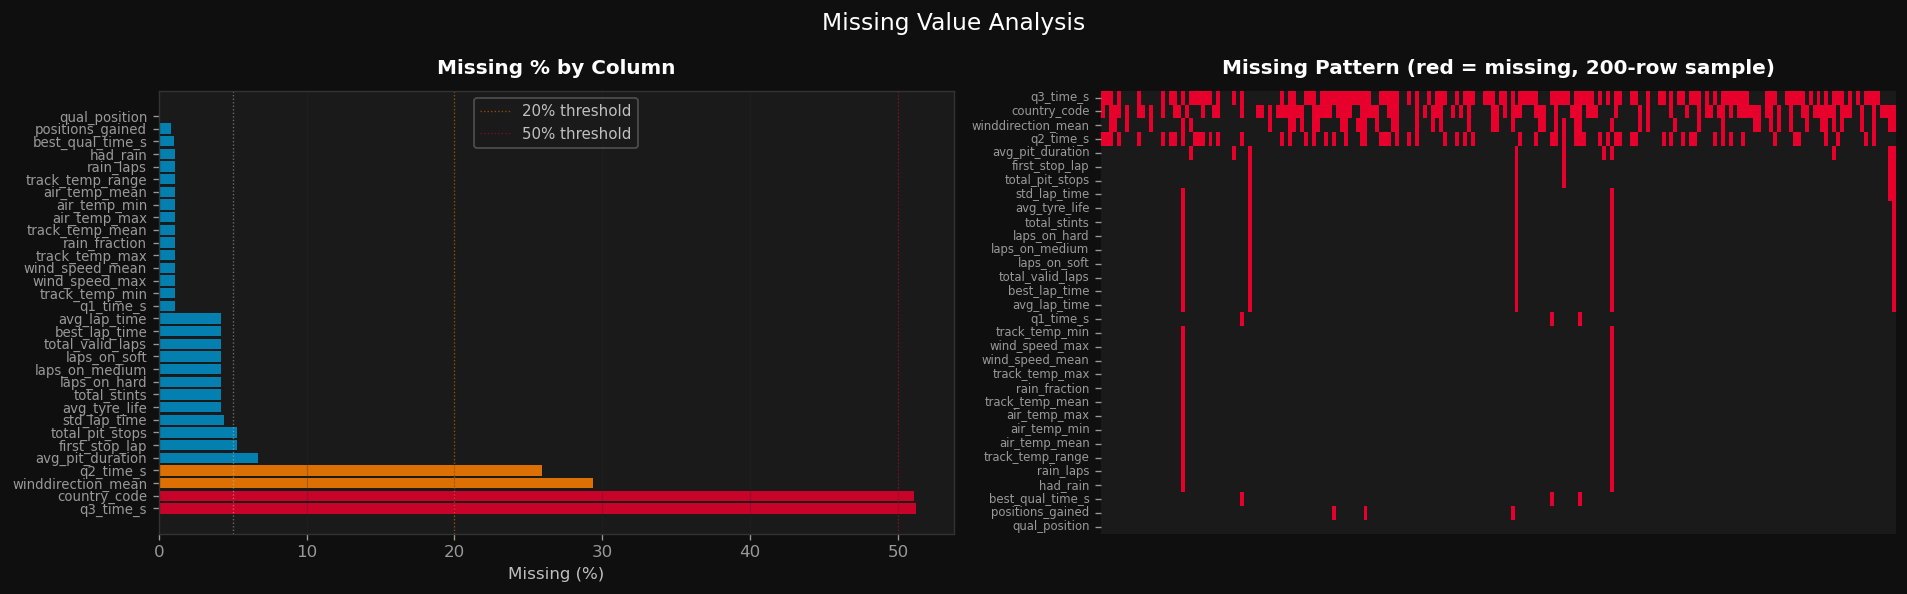


=== MISSING VALUE EXPLANATION ===

  q3_time_s (51.2% missing):
  → Only top 10 qualifiers set a Q3 time — ~51% missing is expected and correct

  q2_time_s (25.9% missing):
  → Only top 15 qualifiers set a Q2 time — ~26% missing is expected and correct

  q1_time_s (1.1% missing):
  → Small number of DNQs or incidents — ~1% missing, negligible

  country_code (51.1% missing):
  → OpenF1 only covers 2023+ — 2022 rows will always be NaN (~24% of dataset)

  winddirection_mean (29.4% missing):
  → Wind direction unreliably recorded (~29% missing) — low value feature

  avg_lap_time (4.2% missing):
  → FastF1 coverage gap — ~4% of races missing from FastF1 data

  total_pit_stops (5.3% missing):
  → A small number of races missing from Jolpica pit stop endpoint (~5%)


In [7]:
# ── Missing value visualisation ────────────────────────────
# Shows patterns: are some columns always missing together?
# (e.g. all FastF1 columns missing for the same races)

missing = df_clean.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Missing Value Analysis', fontsize=14, color=STYLE['white'])

# Bar chart of missing % per column
ax = axes[0]
colours = [STYLE['red'] if pct > 50 else STYLE['orange'] if pct > 20 else STYLE['blue']
           for pct in missing_pct.values]
ax.barh(missing_pct.index, missing_pct.values, color=colours, alpha=0.85)
ax.axvline(5,  color=STYLE['silver'], linestyle=':', linewidth=0.8, alpha=0.5)
ax.axvline(20, color=STYLE['orange'], linestyle=':', linewidth=0.8, alpha=0.5, label='20% threshold')
ax.axvline(50, color=STYLE['red'],    linestyle=':', linewidth=0.8, alpha=0.5, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing % by Column')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=8)

# Heatmap: which rows are missing which columns?
# (helps identify if missingness clusters by year or race)
ax = axes[1]
missing_cols = missing.index.tolist()
sample = df_clean[missing_cols].sample(min(200, len(df_clean)), random_state=42)
sns.heatmap(
    sample.isnull().T,
    ax=ax, cbar=False,
    cmap=['#1a1a1a', STYLE['red']],
    yticklabels=True,
    xticklabels=False
)
ax.set_title('Missing Pattern (red = missing, 200-row sample)')
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_01_missing_values.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

# Explain each group of missing values
print('\n=== MISSING VALUE EXPLANATION ===')
explanations = {
    'q3_time_s':      'Only top 10 qualifiers set a Q3 time — ~51% missing is expected and correct',
    'q2_time_s':      'Only top 15 qualifiers set a Q2 time — ~26% missing is expected and correct',
    'q1_time_s':      'Small number of DNQs or incidents — ~1% missing, negligible',
    'country_code':   'OpenF1 only covers 2023+ — 2022 rows will always be NaN (~24% of dataset)',
    'winddirection_mean': 'Wind direction unreliably recorded (~29% missing) — low value feature',
    'avg_lap_time':   'FastF1 coverage gap — ~4% of races missing from FastF1 data',
    'total_pit_stops': 'A small number of races missing from Jolpica pit stop endpoint (~5%)',
}
for col, explanation in explanations.items():
    if col in missing_pct.index:
        print(f'\n  {col} ({missing_pct[col]:.1f}% missing):')
        print(f'  → {explanation}')

In [14]:
print(missing_pct)

q3_time_s             51.2
country_code          51.1
winddirection_mean    29.4
q2_time_s             25.9
avg_pit_duration       6.7
first_stop_lap         5.3
total_pit_stops        5.3
std_lap_time           4.4
avg_tyre_life          4.2
total_stints           4.2
laps_on_hard           4.2
laps_on_medium         4.2
laps_on_soft           4.2
total_valid_laps       4.2
best_lap_time          4.2
avg_lap_time           4.2
q1_time_s              1.1
track_temp_min         1.1
wind_speed_max         1.1
wind_speed_mean        1.1
track_temp_max         1.1
rain_fraction          1.1
track_temp_mean        1.1
air_temp_max           1.1
air_temp_min           1.1
air_temp_mean          1.1
track_temp_range       1.1
rain_laps              1.1
had_rain               1.1
best_qual_time_s       1.0
positions_gained       0.8
qual_position          0.1
dtype: float64


---
## Section 5 — Target Variable Analysis


- **What type of model to use** — regression (predict a number) or classification (predict a category)
- **Class imbalance** — if 95% of the data is one class, a model that always guesses that class scores 95% accuracy but is useless
- **Evaluation metrics** — what does 'good' actually mean for this prediction?

We have three possible targets:

| Target | ML type | Problem |
|---|---|---|
| `finish_position` | Regression | Predict exact finishing position (1–20) |
| `on_podium` | Binary classification | Will driver finish top 3? |
| `points_finish` | Binary classification | Will driver score points (top 10)? |oints (top 10)? |

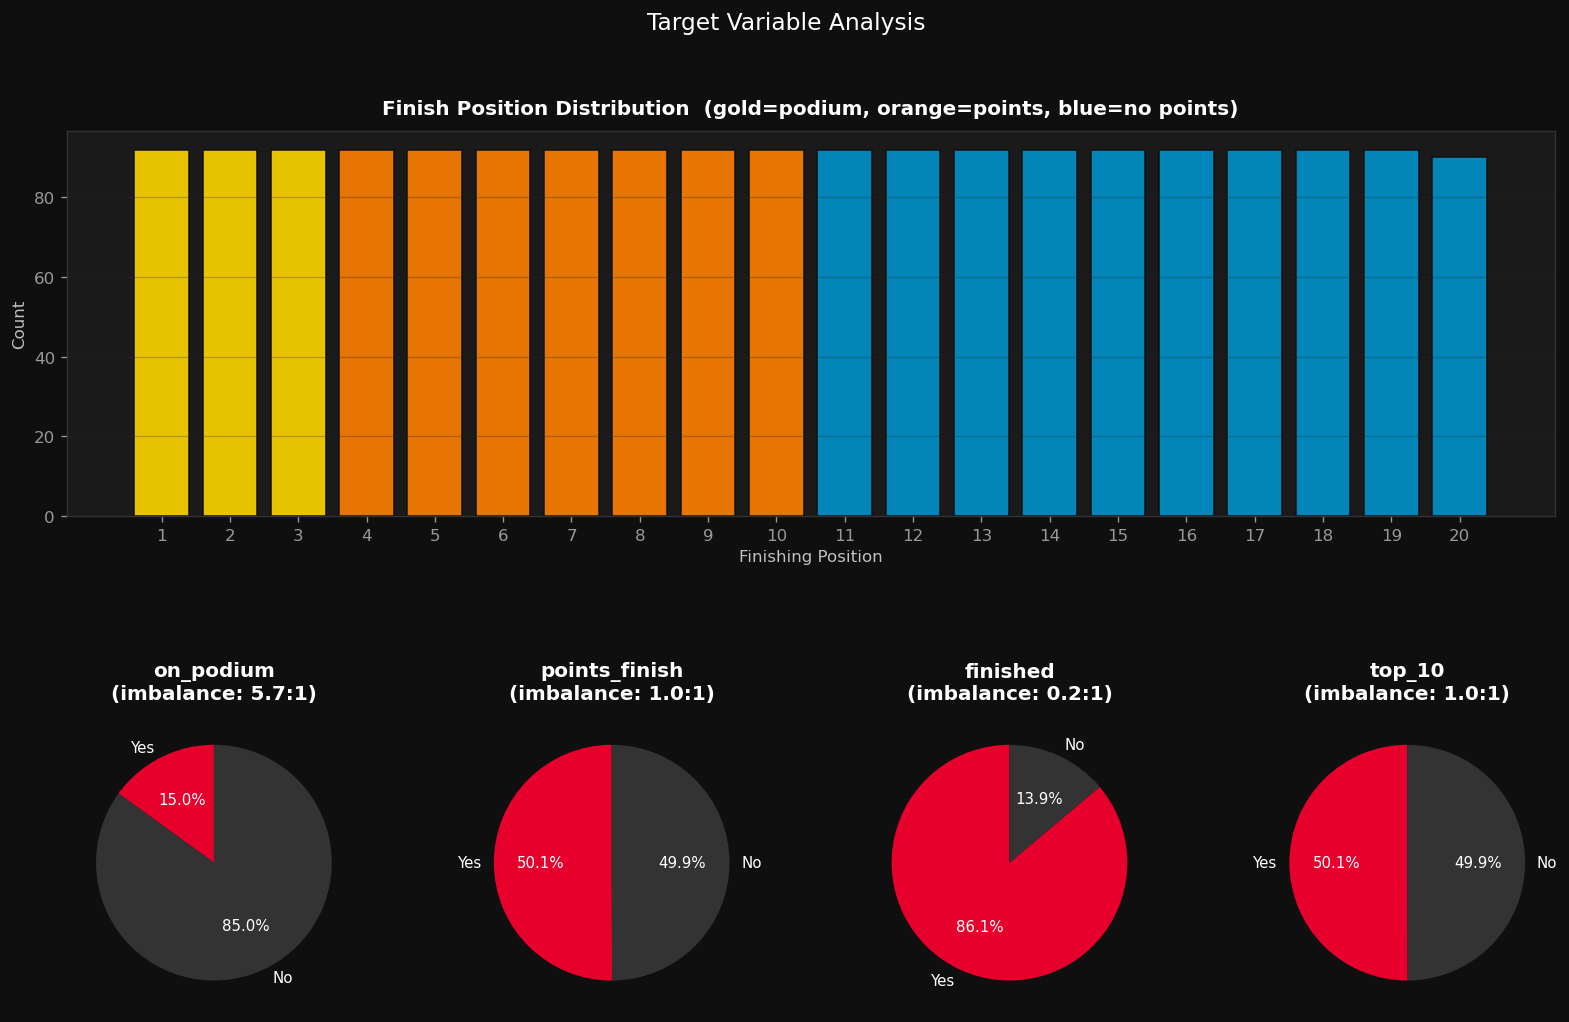

=== CLASS BALANCE ANALYSIS ===

finish_position (regression target):
  Range: 1 – 20
  Mean:  10.5,  Std: 5.8

points (regression target):
  Range: 0 – 26
  Mean:  5.1,  Std: 7.2

on_podium:
  Positive rate: 15.0%
  Imbalance:     5.7:1  → ⚠️  Moderate — use class_weight="balanced"

points_finish:
  Positive rate: 50.1%
  Imbalance:     1.0:1  → ✅ Manageable

finished:
  Positive rate: 86.1%
  Imbalance:     0.2:1  → ✅ Manageable

top_10:
  Positive rate: 50.1%
  Imbalance:     1.0:1  → ✅ Manageable


In [19]:
binary_targets = {}

for t in TARGETS:
    if t in df_clean.columns:          # does this column exist?
        if df_clean[t].dtype == bool:  # is it True/False?
            binary_targets[t] = df_clean[t]  # keep it

n_binary = len(binary_targets)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Target Variable Analysis', fontsize=14, color=STYLE['white'])
gs  = gridspec.GridSpec(2, n_binary, figure=fig, hspace=0.4, wspace=0.35)

# ── Top row: finish position distribution spanning full width ──
ax1 = fig.add_subplot(gs[0, :])
pos_counts = df_clean['finish_position'].value_counts().sort_index()
colours = [
    STYLE['gold']   if p <= 3
    else STYLE['orange'] if p <= 10
    else STYLE['blue']
    for p in pos_counts.index
]
ax1.bar(pos_counts.index, pos_counts.values, color=colours,
        alpha=0.9, edgecolor='#0f0f0f')
ax1.set_xlabel('Finishing Position')
ax1.set_ylabel('Count')
ax1.set_title('Finish Position Distribution  (gold=podium, orange=points, blue=no points)')
ax1.set_xticks(range(1, 21))
ax1.grid(True, axis='y', alpha=0.3)

# ── Bottom row: one pie chart per binary target ────────────────
for idx, (target, series) in enumerate(binary_targets.items()):
    ax = fig.add_subplot(gs[1, idx])
    true_pct  = series.mean() * 100
    false_pct = 100 - true_pct
    ax.pie(
        [true_pct, false_pct],
        labels=['Yes', 'No'],
        colors=[STYLE['red'], '#333333'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'color': STYLE['white'], 'fontsize': 9}
    )
    ratio = false_pct / true_pct
    ax.set_title(f'{target}\n(imbalance: {ratio:.1f}:1)')

plt.savefig(f'{PATHS["plots"]}eda_02_targets.png', dpi=130,
            bbox_inches='tight', facecolor=STYLE['bg_dark'])
plt.show()

# ── Class balance stats ────────────────────────────────────────
print('=== CLASS BALANCE ANALYSIS ===')
for target in TARGETS:
    series = df_clean[target]
    if series.dtype == bool:
        true_pct  = series.mean() * 100
        ratio     = (100 - true_pct) / true_pct
        print(f'\n{target}:')
        print(f'  Positive rate: {true_pct:.1f}%')
        print(f'  Imbalance:     {ratio:.1f}:1', end='  ')
        if ratio > 10:
            print('→ ⚠️  Severe — use class_weight="balanced" or SMOTE')
        elif ratio > 4:
            print('→ ⚠️  Moderate — use class_weight="balanced"')
        else:
            print('→ ✅ Manageable')
    elif pd.api.types.is_numeric_dtype(series):
        print(f'\n{target} (regression target):')
        print(f'  Range: {series.min():.0f} – {series.max():.0f}')
        print(f'  Mean:  {series.mean():.1f},  Std: {series.std():.1f}')

In [16]:
print(df_clean['status'].value_counts().head(20))

status
Finished            1200
Lapped               297
Retired              153
+1 Lap                80
Collision damage      14
Accident              11
Collision             10
Disqualified          10
Did not start          9
Engine                 7
+2 Laps                6
Power Unit             6
Hydraulics             4
Gearbox                4
Undertray              3
Withdrew               3
Water pressure         2
Fuel pressure          2
Spun off               2
Water leak             2
Name: count, dtype: int64


Continuous targets: ['finish_position', 'points']


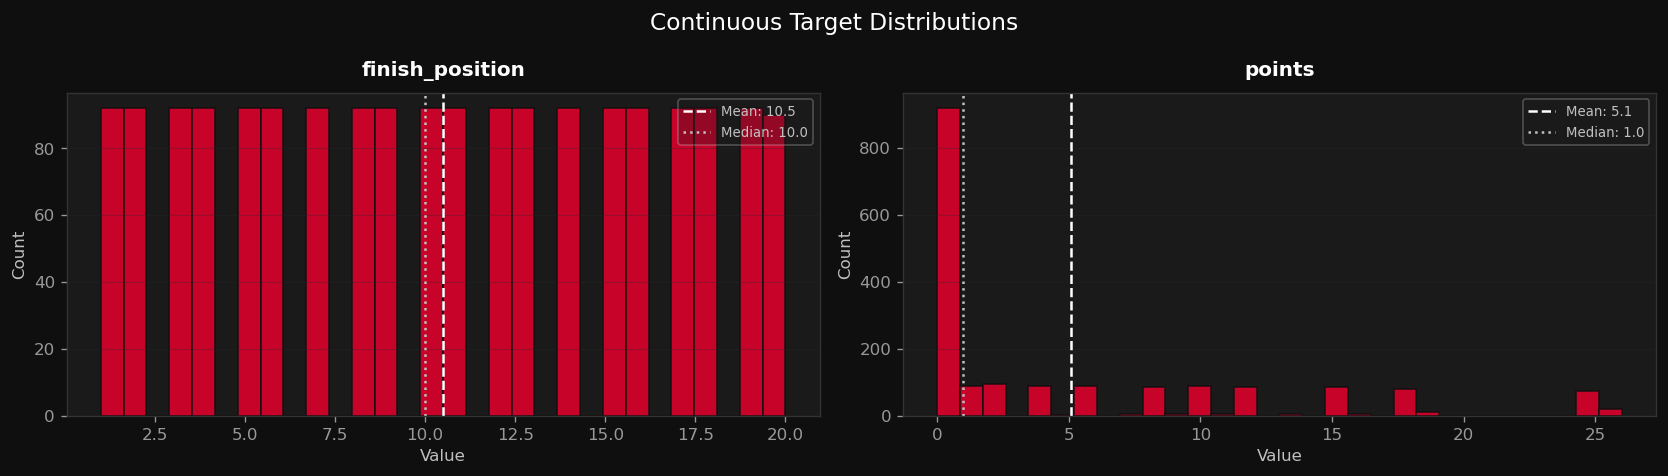


finish_position:
  Min:    1.0
  Max:    20.0
  Mean:   10.5
  Median: 10.0
  Std:    5.8
  Skew:   0.00

points:
  Min:    0.0
  Max:    26.0
  Mean:   5.1
  Median: 1.0
  Std:    7.2
  Skew:   1.39
Corrected finish rate: 86.1%
Corrected DNF rate:    13.9%


In [21]:
# Redefine 'finished' properly
# Lapped drivers genuinely completed the race — they just weren't fast enough
# to stay on the lead lap. They should count as finished.

# Define all statuses that mean the driver actually completed the race
completed_statuses = ['Finished', 'Lapped', '+1 Lap', '+2 Laps']

df_clean['finished'] = df_clean['status'].isin(completed_statuses)
# ── Continuous target distributions ────────────────────────
# finish_position and points are regression targets
# They need histograms, not pie charts

continuous_targets = []

for t in TARGETS:
    if t in df_clean.columns:
        if df_clean[t].dtype != bool:
            continuous_targets.append(t)

print(f'Continuous targets: {continuous_targets}')

fig, axes = plt.subplots(1, len(continuous_targets), figsize=(14, 4))
fig.suptitle('Continuous Target Distributions', fontsize=14, color=STYLE['white'])

for idx, target in enumerate(continuous_targets):
    ax = axes[idx]
    data = df_clean[target].dropna()

    ax.hist(data, bins=30, color=STYLE['red'], alpha=0.85, edgecolor='#0f0f0f')
    ax.axvline(data.mean(),   color=STYLE['white'],  linestyle='--',
               linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color=STYLE['silver'], linestyle=':',
               linewidth=1.5, label=f'Median: {data.median():.1f}')

    ax.set_title(target)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_02b_continuous_targets.png',
            dpi=130, bbox_inches='tight', facecolor=STYLE['bg_dark'])
plt.show()

# Stats
for target in continuous_targets:
    data = df_clean[target].dropna()
    print(f'\n{target}:')
    print(f'  Min:    {data.min():.1f}')
    print(f'  Max:    {data.max():.1f}')
    print(f'  Mean:   {data.mean():.1f}')
    print(f'  Median: {data.median():.1f}')
    print(f'  Std:    {data.std():.1f}')
    print(f'  Skew:   {data.skew():.2f}')
# Check the new rate
real_dnf_rate = (1 - df_clean['finished'].mean()) * 100
print(f'Corrected finish rate: {df_clean["finished"].mean()*100:.1f}%')
print(f'Corrected DNF rate:    {real_dnf_rate:.1f}%')

---
## Section 6 — Feature Distributions

### What are we doing here?

Before looking at relationships between features, look at each feature individually. You want to know:

- **Is the distribution normal or skewed?** — Some models (like linear regression) assume normality. Heavy skew might need log transformation.
- **Are there outliers?** — A single extreme value can destroy a model's performance.
- **Does the range make sense?** — If `grid_position` goes from -5 to 200, something is wrong.

We plot distributions for all numeric features automatically. No hardcoding which columns to plot.


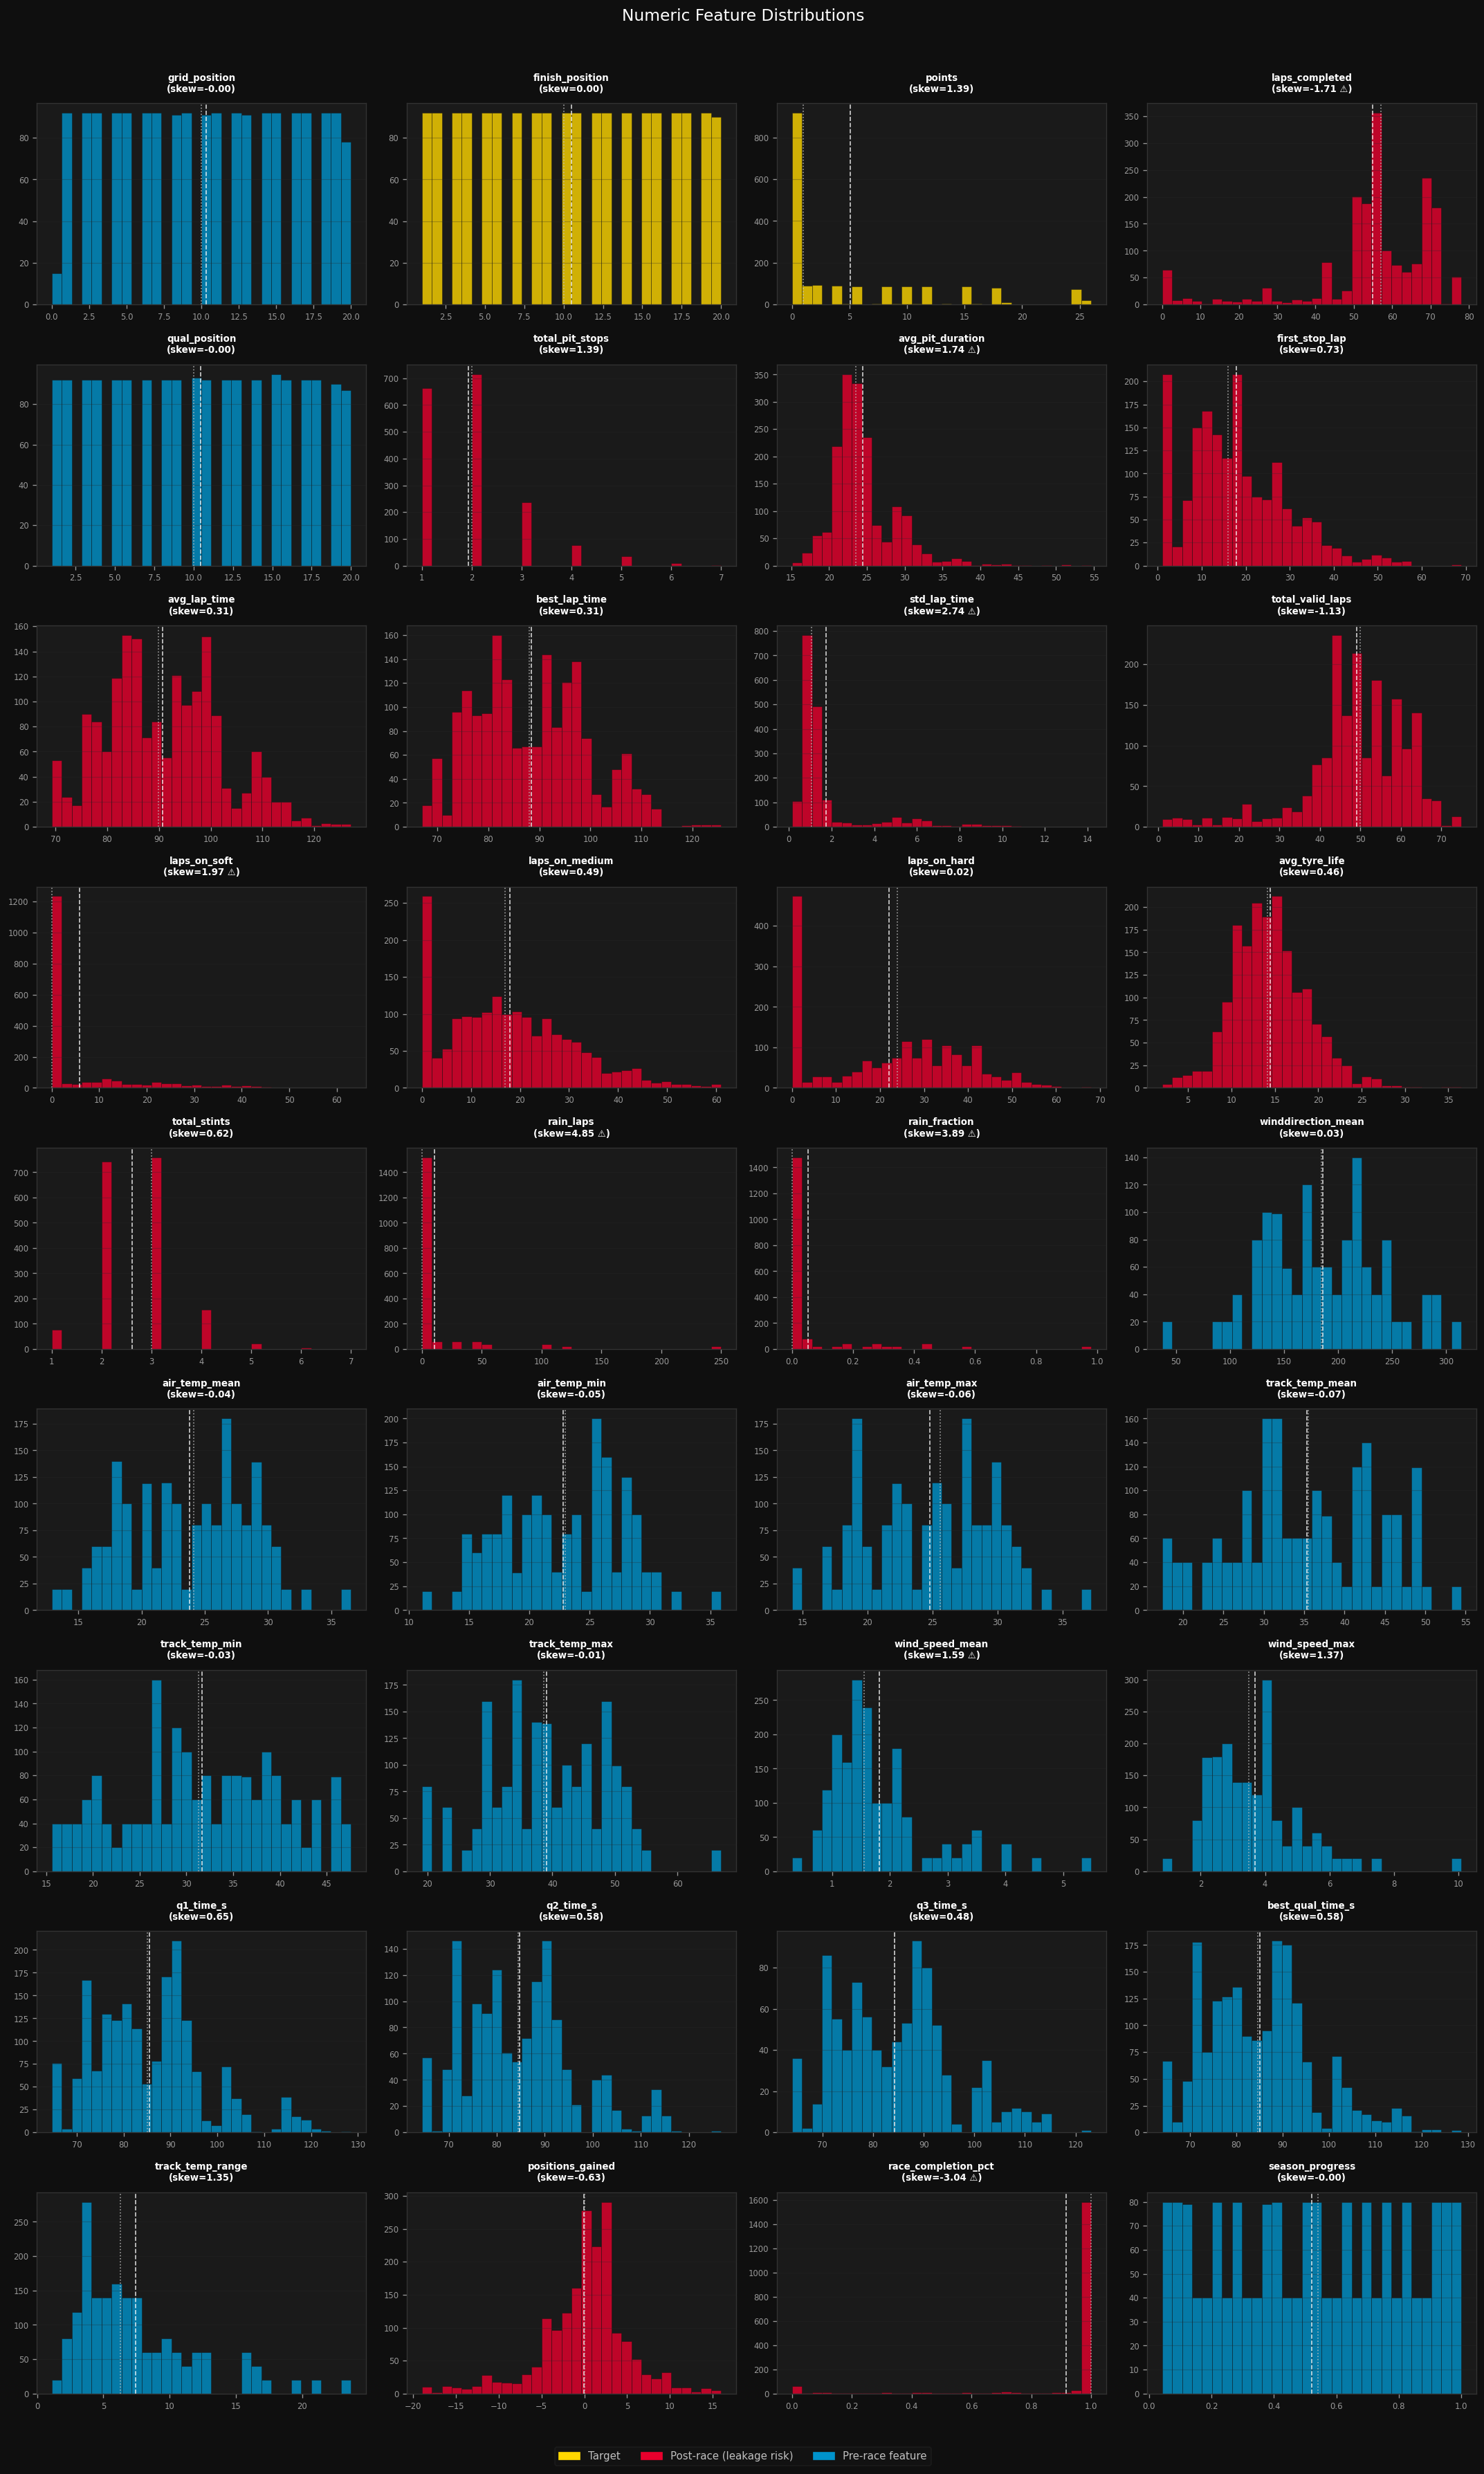


Highly skewed features (|skew| > 1.5) — consider log transform in feature engineering:
  laps_completed                  skew=-1.71
  avg_pit_duration                skew=1.74
  std_lap_time                    skew=2.74
  laps_on_soft                    skew=1.97
  rain_laps                       skew=4.85
  rain_fraction                   skew=3.89
  wind_speed_mean                 skew=1.59
  race_completion_pct             skew=-3.04


In [20]:
# ── Auto-detect numeric columns to plot ────────────────────
# Only plot columns with enough unique values to make a histogram meaningful
# and with enough non-null values to be reliable

numeric_cols = []

for col in df_clean.columns:

    # First check — is this column numeric?
    if df_clean[col].dtype not in [np.float64, np.int64, np.float32, np.int32]:
        continue   # skip it, not a number column

    # Second check — does it have more than 5 unique values?
    # A column with only 1, 2, 3, 4, 5 unique values isn't worth a histogram
    if df_clean[col].nunique() <= 5:
        continue   # skip it, too few unique values

    # Third check — does it have enough data points?
    # A column with only 10 non-null values isn't meaningful to plot
    if df_clean[col].notna().sum() <= 100:
        continue   # skip it, too few data points

    # Fourth check — is it an identifier column?
    # year, round etc. are numbers but not meaningful to analyse
    if col in IDENTIFIERS:
        continue   # skip it, it's just a label

    # Passed all checks — keep it
    numeric_cols.append(col)

print(f'Columns to plot: {len(numeric_cols)}')
print(numeric_cols)

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.2))
fig.suptitle('Numeric Feature Distributions', fontsize=14, color=STYLE['white'], y=1.01)
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax    = axes[idx]
    data  = df_clean[col].dropna()
    role  = COLUMN_CATALOGUE.get(col, {}).get('role', 'unknown')

    # Colour by role so you can visually separate targets from features
    colour = (
        STYLE['gold']   if role == 'target'
        else STYLE['red']  if role == 'post_race_leakage'
        else STYLE['blue'] if role == 'pre_race_feature'
        else STYLE['silver']
    )

    ax.hist(data, bins=30, color=colour, alpha=0.8, edgecolor='#0f0f0f', linewidth=0.3)
    ax.axvline(data.mean(),   color=STYLE['white'],  linestyle='--', linewidth=1, alpha=0.8)
    ax.axvline(data.median(), color=STYLE['silver'], linestyle=':',  linewidth=1, alpha=0.8)

    # Compute skewness — a measure of how asymmetric the distribution is
    # |skew| > 1 means significantly skewed, might need log transform
    skew = data.skew()
    skew_label = f'skew={skew:.2f}' + (' ⚠️' if abs(skew) > 1.5 else '')

    ax.set_title(f'{col}\n({skew_label})', fontsize=8)
    ax.set_xlabel('')
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(labelsize=7)

# Hide unused subplot panels
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

# Legend for role colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(color=STYLE['gold'],   label='Target'),
    Patch(color=STYLE['red'],    label='Post-race (leakage risk)'),
    Patch(color=STYLE['blue'],   label='Pre-race feature'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), fontsize=9,
           facecolor=STYLE['bg_panel'], edgecolor='#333333')

plt.tight_layout()
plt.savefig(f'{PATHS["plots"]}eda_03_distributions.png', dpi=130, bbox_inches='tight',
            facecolor=STYLE['bg_dark'])
plt.show()

# Flag highly skewed features that may need transformation
print('\nHighly skewed features (|skew| > 1.5) — consider log transform in feature engineering:')
for col in numeric_cols:
    skew = df_clean[col].skew()
    if abs(skew) > 1.5:
        print(f'  {col:30s}  skew={skew:.2f}')